# 2a. Static Expert Parameters, Uniform Distribution

**Scenario**: Synthetic animals with fixed expert-level parameters,
uniform stimulus distribution. The simplest case.

**Tests**:
1. Model identification (GS + SBI)
2. Parameter recovery (GS + SBI) — can we get the true params back?
3. SBC calibration — are SBI posteriors well-calibrated?

In [ ]:
%matplotlib inline
import os, sys
from pathlib import Path

_NOTEBOOK_DIR = Path(os.path.abspath(''))
_NOTEBOOK_ROOT = _NOTEBOOK_DIR.parent
_PROJECT_ROOT = _NOTEBOOK_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))
if str(_NOTEBOOK_ROOT) not in sys.path:
	sys.path.insert(0, str(_NOTEBOOK_ROOT))

from shared_setup import *

import time
import pickle
from analysis.validation import (
    make_synthetic_cohort,
    run_gs_model_id, run_sbi_model_id, summarise_agreement,
)

SBI_OK = False
try:
    import torch
    SBI_OK = True
    print(f'SBI available (torch={torch.__version__})')
except ImportError as e:
    print(f'SBI not available: {e}')

SBI available (torch=2.5.1)


## 1. Configuration

In [2]:
QUICK = True

if QUICK:
    N_SYNTHETIC = 3; N_GS_SEEDS = 2; BURN_IN = 500
    N_SBI_SIMS = 1_000; N_GENERIC_TRIALS = 300; N_CV_REPEATS = 4
    N_SBC_RUNS = 50; N_SBI_RECOVERY = 20
else:
    N_SYNTHETIC = 5; N_GS_SEEDS = 4; BURN_IN = 1000
    N_SBI_SIMS = 20_000; N_GENERIC_TRIALS = 2500; N_CV_REPEATS = 32
    N_SBC_RUNS = 500; N_SBI_RECOVERY = 100

SEED = 42; N_SESSIONS = 15; TRIALS_PER_SESSION = 350
print(f'Mode: {"QUICK" if QUICK else "FULL"}')

Mode: QUICK


## 2. Generate Synthetic Animals

In [3]:
animals = make_synthetic_cohort(
    n_per_model=N_SYNTHETIC, n_sessions=N_SESSIONS,
    trials_per_session=TRIALS_PER_SESSION,
    burn_in=BURN_IN, seed=SEED,
)
print(f'{len(animals)} animals ({N_SYNTHETIC} BE + {N_SYNTHETIC} SC)')
for a in animals:
    accs = [s.stats(['accuracy'])['accuracy'] for s in a['sessions']]
    print(f'  {a["animal_id"]}: {a["true_model"]} acc={np.mean(accs):.2f}')

6 animals (3 BE + 3 SC)
  BE_static_00: BE acc=0.56
  BE_static_01: BE acc=0.65
  BE_static_02: BE acc=0.65
  SC_static_00: SC acc=0.79
  SC_static_01: SC acc=0.77
  SC_static_02: SC acc=0.79


## 3. Grid-Search: Model ID


In [4]:
print('=== Grid-Search Model Identification ===')
gs_df = run_gs_model_id(animals, n_seeds=N_GS_SEEDS, burn_in=BURN_IN)
print(f'\nAccuracy: {gs_df["gs_correct"].sum()}/{len(gs_df)} '
      f'({gs_df["gs_correct"].mean():.0%})')

=== Grid-Search Model Identification ===
  GS [update_matrix] BE_static_00 [BE]... BE ✓
  GS [update_matrix] BE_static_01 [BE]... BE ✓
  GS [update_matrix] BE_static_02 [BE]... BE ✓
  GS [update_matrix] SC_static_00 [SC]... BE ✗
  GS [update_matrix] SC_static_01 [SC]... BE ✗
  GS [update_matrix] SC_static_02 [SC]... SC ✓

Accuracy: 4/6 (67%)


### 3b. Grid-Search Parameter Recovery

For correctly-identified animals: how close are the recovered
parameters to the true values?

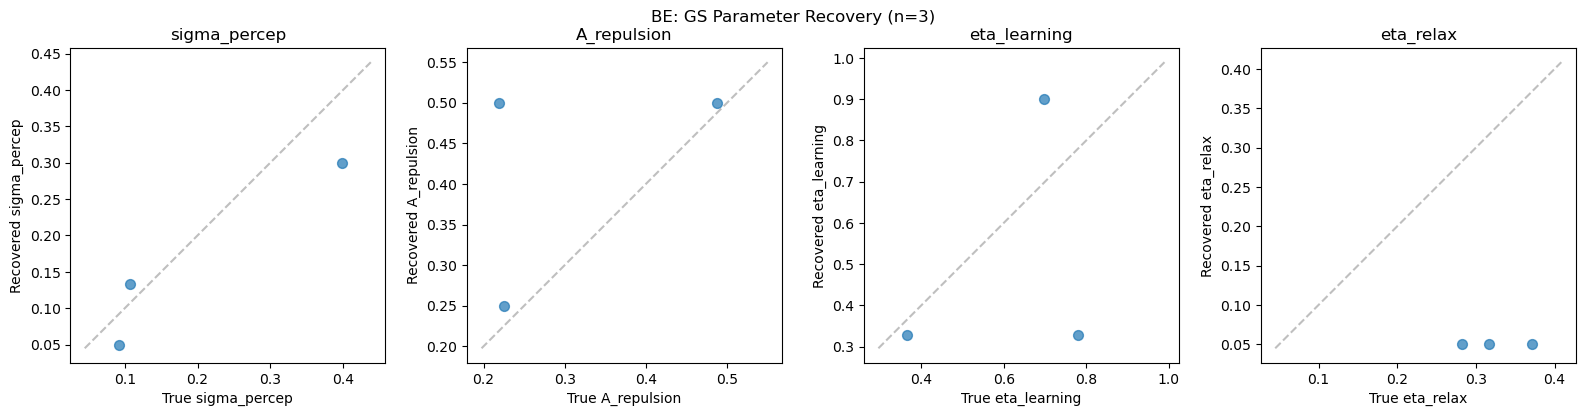

SC: too few correct recoveries for scatter


In [5]:
# ── GS parameter recovery scatter ─────────────────────────────────────────
for true_model in ['BE', 'SC']:
    sub_df = gs_df[(gs_df['true_model'] == true_model) & gs_df['gs_correct']]
    sub_animals = [a for a in animals
                   if a['animal_id'] in sub_df['animal_id'].values]

    if len(sub_animals) < 2:
        print(f'{true_model}: too few correct recoveries for scatter')
        continue

    param_names = sub_animals[0]['true_params'].get_param_names()
    n_params = len(param_names)

    fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 4))
    if n_params == 1: axes = [axes]

    for ax, pname in zip(axes, param_names):
        true_vals = [getattr(a['true_params'], pname) for a in sub_animals]
        rec_vals = []
        for a in sub_animals:
            row = sub_df[sub_df['animal_id'] == a['animal_id']].iloc[0]
            rp = row.get('gs_recovered_params', {})
            rec_vals.append(rp.get(pname, rp.get('sigma_noise' if pname == 'sigma_percep' else pname, np.nan)))

        ax.scatter(true_vals, rec_vals, alpha=0.7, s=50)
        lims = [min(min(true_vals), min(rec_vals)) * 0.9,
                max(max(true_vals), max(rec_vals)) * 1.1]
        ax.plot(lims, lims, '--', color='grey', alpha=0.5)
        ax.set_xlabel(f'True {pname}')
        ax.set_ylabel(f'Recovered {pname}')
        ax.set_title(pname)
        ax.set_aspect('equal')

    fig.suptitle(f'{true_model}: GS Parameter Recovery (n={len(sub_animals)})')
    plt.tight_layout()
    plt.show()

## 4. SBI: Model ID

In [6]:
sbi_df = pd.DataFrame()
be_snpe, sc_snpe = None, None

if SBI_OK:
    print('=== SBI Model Identification ===')
    sbi_df, be_snpe, sc_snpe = run_sbi_model_id(
        animals, n_sbi_sims=N_SBI_SIMS,
        n_generic_trials=N_GENERIC_TRIALS,
        n_cv_repeats=N_CV_REPEATS, burn_in=BURN_IN, seed=SEED,
        return_networks=True,
    )
    print(f'\nAccuracy: {sbi_df["sbi_correct"].sum()}/{len(sbi_df)} '
          f'({sbi_df["sbi_correct"].mean():.0%})')
else:
    print('SBI not available')

=== SBI Model Identification ===
  Training SNPE...

Training amortised SNPE [BE] (1,000 sims, 300 trials, burn_in=500)...
  Simulating...
  917/1000 valid (92%)
 Neural network successfully converged after 124 epochs.  Done in 1.4 min

Training amortised SNPE [SC] (1,000 sims, 300 trials, burn_in=500)...
  Simulating...
  995/1000 valid (100%)
 Training neural network. Epochs trained: 6

/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [2] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 151 epochs.  Done in 2.2 min
  SBI [update_matrix] BE_static_00 [BE]... 

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

SC ✓

Accuracy: 6/6 (100%)


### 4b. SBI Parameter Recovery

Sample from prior → simulate → condition posterior → extract median.
Compare median to true values.


=== BE SBI Recovery ===


Recovery:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Recovery:   5%|▌         | 1/20 [00:00<00:04,  3.91it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

Recovery:  85%|████████▌ | 17/20 [00:03<00:00,  5.17it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Recovery:  95%|█████████▌| 19/20 [00:03<00:00,  5.63it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Recovery: 100%|██████████| 20/20 [00:03<00:00,  5.31it/s]
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/diagnostics.py:468: UserWarning: Removed 2/20 invalid recovery runs
  warnings.warn(f"Removed {n_invalid}/{n_recoveries} invalid recovery runs")


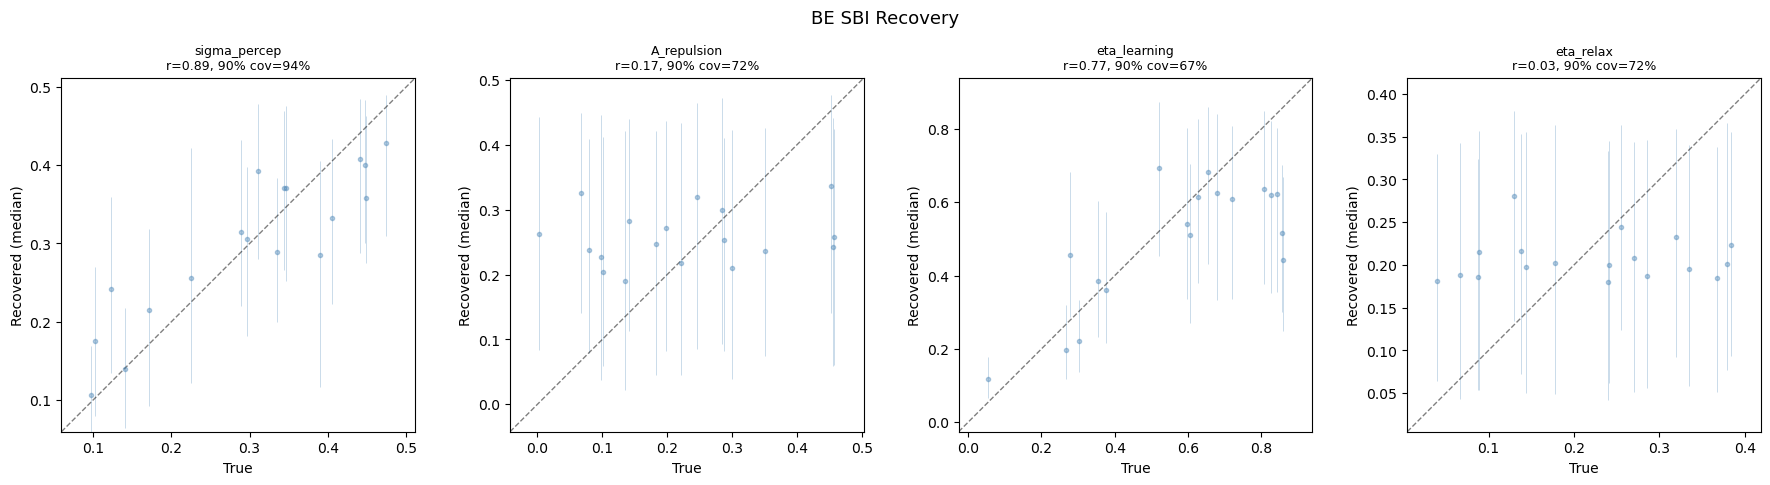


=== SC SBI Recovery ===


Recovery:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Recovery:   5%|▌         | 1/20 [00:00<00:06,  2.81it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

Recovery:  90%|█████████ | 18/20 [00:05<00:00,  3.19it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Recovery:  95%|█████████▌| 19/20 [00:05<00:00,  3.52it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Recovery: 100%|██████████| 20/20 [00:05<00:00,  3.38it/s]


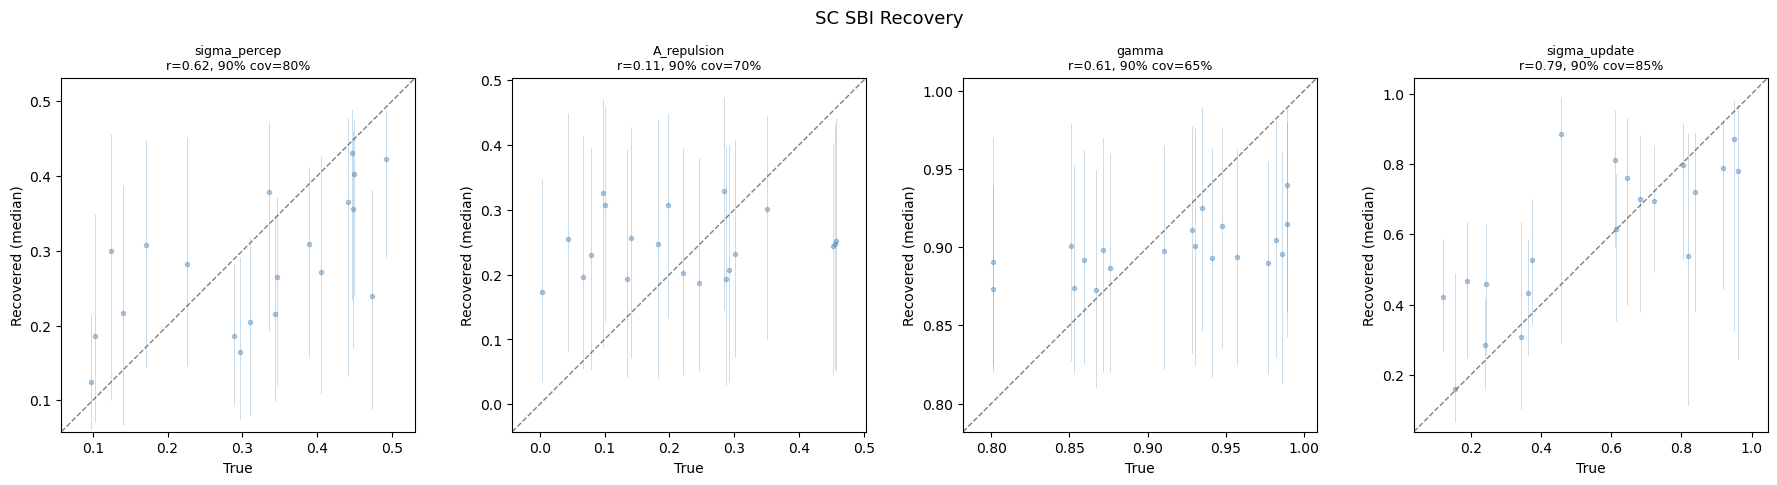

In [7]:
if SBI_OK and be_snpe is not None:
    from inference.diagnostics import (
        parameter_recovery, plot_recovery_scatter,
    )

    for mt, snpe in [('BE', be_snpe), ('SC', sc_snpe)]:
        print(f'\n=== {mt} SBI Recovery ===')
        try:
            rec = parameter_recovery(
                posterior=snpe['posterior'],
                simulator=snpe['sbi_sim'],
                prior=snpe['prior'],
                n_recoveries=N_SBI_RECOVERY,
                n_posterior_samples=200,
                seed=SEED,
                param_names=snpe['param_names'],
            )
            fig = plot_recovery_scatter(rec, title=f'{mt} SBI Recovery')
            plt.show()
        except Exception as e:
            print(f'  Failed: {e}')

### 4c. SBC Calibration

Rank histograms: if the posterior is well-calibrated, ranks should
be uniformly distributed.


=== BE SBC ===
sbi built-in SBC failed (cannot import name 'run_sbc' from 'sbi.analysis' (/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/analysis/__init__.py)), using manual implementation...


SBC:   0%|          | 0/50 [00:00<?, ?it/s]/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/diagnostics.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x_star, dtype=torch.float32).unsqueeze(0)
SBC:   2%|▏         | 1/50 [00:00<00:15,  3.25it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

SBC:   4%|▍         | 2/50 [00:00<00:10,  4.60it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

SBC:  96%|█████████▌| 48/50 [00:09<00:00,  5.60it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

SBC:  98%|█████████▊| 49/50 [00:09<00:00,  5.18it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

SBC: 100%|██████████| 50/50 [00:09<00:00,  5.27it/s]
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/diagnostics.py:165: UserWarning: Removed 5/50 invalid SBC runs
  warnings.warn(f"Removed {n_invalid}/{n_sbc_runs} invalid SBC runs")


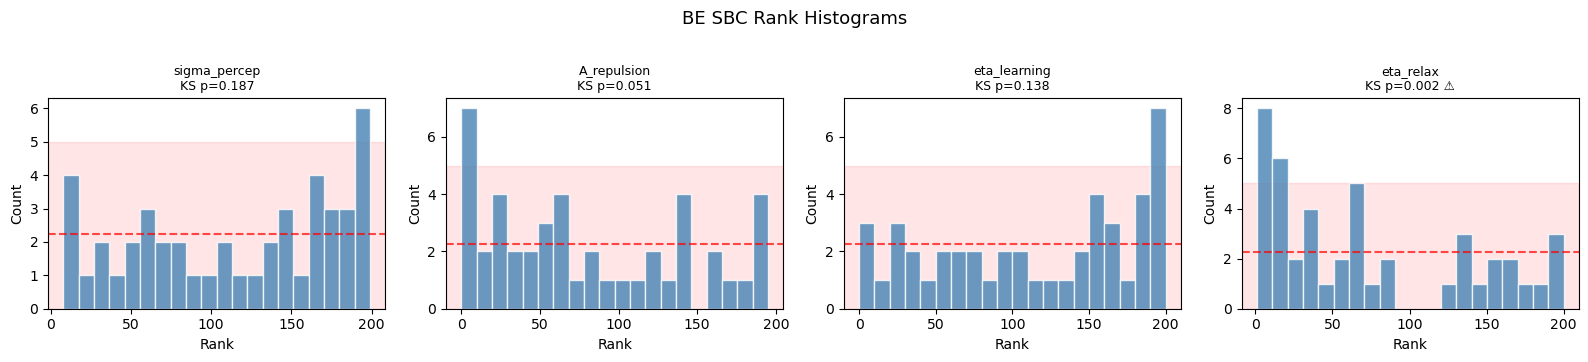


=== SC SBC ===
sbi built-in SBC failed (cannot import name 'run_sbc' from 'sbi.analysis' (/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/analysis/__init__.py)), using manual implementation...


SBC:   0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

SBC:   2%|▏         | 1/50 [00:00<00:20,  2.36it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

SBC:  96%|█████████▌| 48/50 [00:12<00:00,  3.33it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

SBC:  98%|█████████▊| 49/50 [00:12<00:00,  3.16it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

SBC: 100%|██████████| 50/50 [00:13<00:00,  3.84it/s]
/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/diagnostics.py:165: UserWarning: Removed 2/50 invalid SBC runs
  warnings.warn(f"Removed {n_invalid}/{n_sbc_runs} invalid SBC runs")


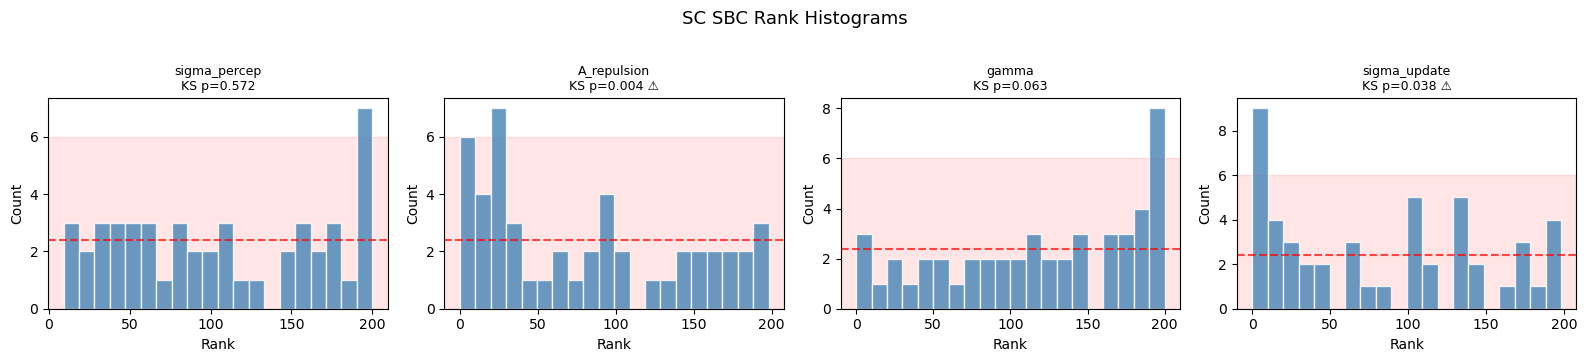

In [8]:
if SBI_OK and be_snpe is not None:
    from inference.diagnostics import run_sbc, plot_sbc_ranks

    for mt, snpe in [('BE', be_snpe), ('SC', sc_snpe)]:
        print(f'\n=== {mt} SBC ===')
        try:
            sbc = run_sbc(
                posterior=snpe['posterior'],
                simulator=snpe['sbi_sim'],
                prior=snpe['prior'],
                n_sbc_runs=N_SBC_RUNS,
                n_posterior_samples=200,
                seed=SEED,
                param_names=snpe['param_names'],
            )
            fig = plot_sbc_ranks(sbc, title=f'{mt} SBC Rank Histograms')
            plt.show()
        except Exception as e:
            print(f'  Failed: {e}')

## 5. Agreement

In [9]:
merged = summarise_agreement(gs_df, sbi_df, 'Static Uniform')
print()
print(merged.to_string(index=False))


  Static Uniform
  GS accuracy: 4/6 (67%)
  SBI accuracy: 6/6 (100%)
  GS-SBI agreement: 67%
  Both correct:     67%

   animal_id true_model gs_winner  gs_correct  gs_be_mean  gs_sc_mean                                                                                               gs_recovered_params    fit_target sbi_winner  sbi_correct  sbi_be_mean  sbi_sc_mean        sbi_p        method
BE_static_00         BE        BE        True    0.004445    0.023371                  {'sigma_percep': 0.3, 'A_repulsion': 0.5, 'eta_learning': 0.3285714285714286, 'eta_relax': 0.05} update_matrix         BE         True     0.003322     0.099348 1.671091e-11 update_matrix
BE_static_01         BE        BE        True    0.005873    0.008707                                {'sigma_percep': 0.05, 'A_repulsion': 0.5, 'eta_learning': 0.9, 'eta_relax': 0.05} update_matrix         BE         True     0.003094     0.062803 2.820738e-10 update_matrix
BE_static_02         BE        BE        True    0.01010

## 6. Save

In [10]:
save_path = Path('../results/validation/2a_static_uniform.pkl')
save_path.parent.mkdir(parents=True, exist_ok=True)
with open(save_path, 'wb') as f:
    pickle.dump({'gs': gs_df, 'sbi': sbi_df if SBI_OK else None,
                 'scenario': '2a_static_uniform'}, f)
print(f'Saved to {save_path}')

Saved to ../results/validation/2a_static_uniform.pkl
